In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [59]:
#Prepare text files for JJDFTX
export_hwannier("wannier");
export_heph("wannier");
export_momentum("wannier");

In [3]:
Hwannier, cell_map = hwannier("wannier"), np.loadtxt("wannier.map.txt");
force_matrix, cellph_map = phonon_force_matrix("totalE");
Heph, celleph_map = hephwannier("wannier"), np.loadtxt("wannier.mapeph.txt");
Pwannier = pwannier("wannier");
lattice_vectors = loadlattice("totalE.out");

In [120]:
E, DOS = density_of_states(Hwannier, cell_map, histogram_width=10, mesh=20, num_blocks=500, degeneracy=2)

([-12.876058979099838, -12.776078107842025, -12.67609723658421, -12.576116365326397, -12.476135494068583, -12.37615462281077, -12.276173751552955, -12.176192880295142, -12.076212009037327, -11.976231137779514  …  15.418527586861451, 15.518508458119264, 15.618489329377077, 15.718470200634894, 15.818451071892706, 15.91843194315052, 16.018412814408332, 16.118393685666145, 16.218374556923962, 16.318355428181775], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [124]:
# Find Chemical Potential
Es, μs = find_chemical_potential(E, DOS)

([-12.776078107842025, -12.67609723658421, -12.576116365326397, -12.476135494068583, -12.37615462281077, -12.276173751552955, -12.176192880295142, -12.076212009037327, -11.976231137779514, -11.876250266521701  …  15.418527586861451, 15.518508458119264, 15.618489329377077, 15.718470200634894, 15.818451071892706, 15.91843194315052, 16.018412814408332, 16.118393685666145, 16.218374556923962, 16.318355428181775], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  17.99655682640648, 17.99655682640648, 17.99655682640648, 17.99655682640648, 17.99655682640648, 17.99655682640648, 17.99655682640648, 17.996556826406476, 17.996556826406476, 17.996556826406476])

In [126]:
μ = Es[argmin(abs.(μs .- 11))]
dos_μ = DOS[argmin(abs.(E .- μ))]
println("Fermi energy is: $(μ)")
println("DOS at Fermi energy is: $(dos_μ)")

Fermi energy is: -4.777608407216926
DOS at Fermi energy is: 0.23040000000000002


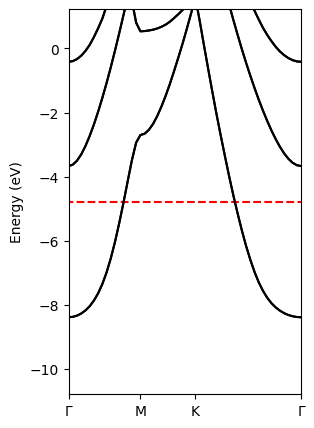

PyObject Text(23.999999999999993, 0.5, 'Energy (eV)')

In [225]:
figure(figsize=(3, 5))
plot_bands(Hwannier, cell_map, kpointsfile="../../bandstruct.kpoints", color="black", whichbands=[6, 7, 8])
plot_bands(Hwannier, cell_map, kpointsfile="../../bandstruct.kpoints", color="black", whichbands=[6, 7, 8])

label_plots("../../bandstruct.kpoints.in", "../../bandstruct.kpoints")
ylim(-6-4.78, 6-4.78)
hlines([-4.78], -100, 100, color="red", linestyle="dashed")
ylabel("Energy (eV)")

In [5]:
tau_histogram_inv = zeros(100)
tau_gaussian_inv = zeros(100)
tau_lorentzian_inv = zeros(100)
N = 200
for i in 1:N
    tau_histogram_inv += 1 ./ np.loadtxt("boltzmann/histogram-$i.txt") 
    tau_gaussian_inv += 1 ./ np.loadtxt("boltzmann/gaussian-$i.txt") 
    tau_lorentzian_inv += 1 ./ np.loadtxt("boltzmann/lorentzian-$i.txt") 
end
tau_histogram_inv *= 1/N;
tau_gaussian_inv *= 1/N;
tau_lorentzian_inv *= 1/N;
tau_lorentzian = 1 ./ tau_lorentzian_inv;
tau_gaussian = 1 ./ tau_gaussian_inv;
tau_histogram = 1 ./ tau_histogram_inv;
fw_x, fw_y = [col for col in eachcol(np.loadtxt("fwdir/tauAC.dat"))];

In [144]:
JJDFTX.dosatmu(Hwannier, cell_map, -4.78, Val(2), Val(:lorentzian), histogram_width=1, mesh=10, num_blocks=1000, esmearing=0.005)

0.1180964737605811

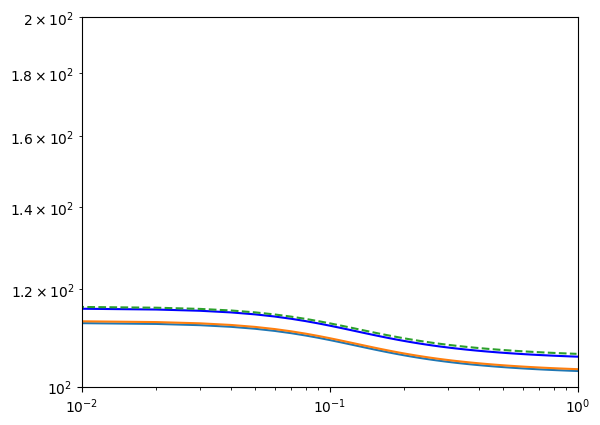

(0.01, 1)

In [4]:
loglog(collect(0.01:0.01:1), tau_histogram)
loglog(collect(0.01:0.01:1), tau_gaussian)
loglog(collect(0.01:0.01:1), tau_lorentzian, color="blue")

loglog(fw_x, fw_y, linestyle="dashed")
ylim(100, 200)
xlim(0.01, 1)

In [6]:
tau_allen_inv = zeros(100)
N = 200
for i in 1:N
    tau_allen_inv += (1 ./ np.loadtxt("boltzmann/boltzmann-$i.txt")) / N
end
tau_allen = 1 ./ tau_allen_inv;

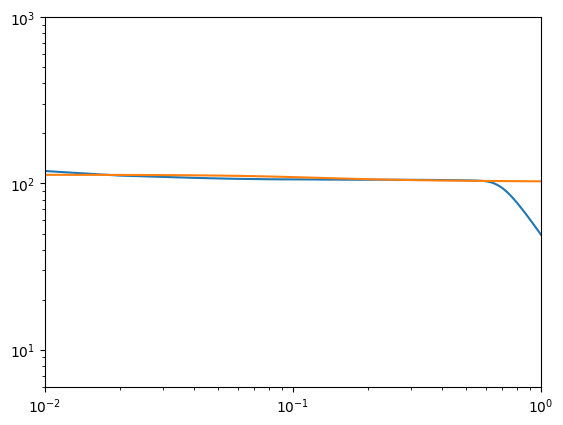

(6, 1000)

In [7]:
loglog(collect(0.01:0.01:1), tau_allen)
loglog(collect(0.01:0.01:1), tau_histogram)
xlim(0.01, 1)
ylim(6, 1000)

In [8]:
np.savetxt("tau.txt", hcat([tau_histogram, tau_gaussian, tau_lorentzian, tau_allen]...), header="hist, gauss, lorentz, allen")

In [9]:
tau_histogram, tau_gaussian, tau_lorentzian, tau_allen = [col for col in eachcol(np.loadtxt("tau.txt"))];

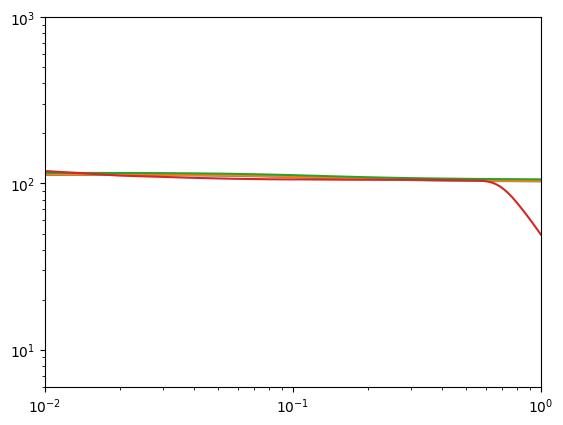

(0.01, 1)

In [10]:
omegas = collect(0.01:0.01:1)
loglog(omegas, tau_histogram)
loglog(omegas, tau_gaussian)
loglog(omegas, tau_lorentzian)
loglog(omegas, tau_allen)

ylim(6, 1000)
xlim(0.01, 1)